In [1]:
#Import Libraries & Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("C:/Users/rithu/OneDrive/Desktop/Rithul/loan_approval_synthetic_8000.csv")

# Preview
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,1,Graduate,No,9250,7142,456,240,0,Urban,1
1,Female,Yes,1,Graduate,No,7273,6289,382,120,1,Urban,1
2,Male,No,1,Graduate,No,10697,5021,118,360,1,Urban,1
3,Male,Yes,2,Not Graduate,No,7628,6870,107,360,1,Urban,1
4,Male,Yes,0,Graduate,No,6913,6308,256,180,1,Rural,1


In [2]:
#Dataset Info & Basic Checks
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Gender             8000 non-null   object
 1   Married            8000 non-null   object
 2   Dependents         8000 non-null   int64 
 3   Education          8000 non-null   object
 4   Self_Employed      8000 non-null   object
 5   ApplicantIncome    8000 non-null   int64 
 6   CoapplicantIncome  8000 non-null   int64 
 7   LoanAmount         8000 non-null   int64 
 8   Loan_Amount_Term   8000 non-null   int64 
 9   Credit_History     8000 non-null   int64 
 10  Property_Area      8000 non-null   object
 11  Loan_Status        8000 non-null   int64 
dtypes: int64(7), object(5)
memory usage: 750.1+ KB


Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

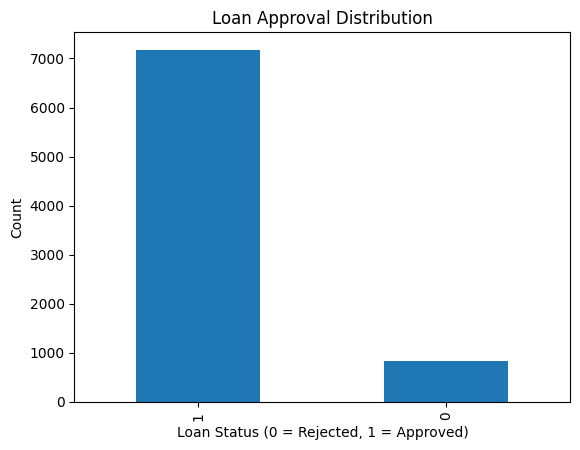

In [3]:
#Loan Status Distribution
plt.figure()
data["Loan_Status"].value_counts().plot(kind="bar")
plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status (0 = Rejected, 1 = Approved)")
plt.ylabel("Count")
plt.show()

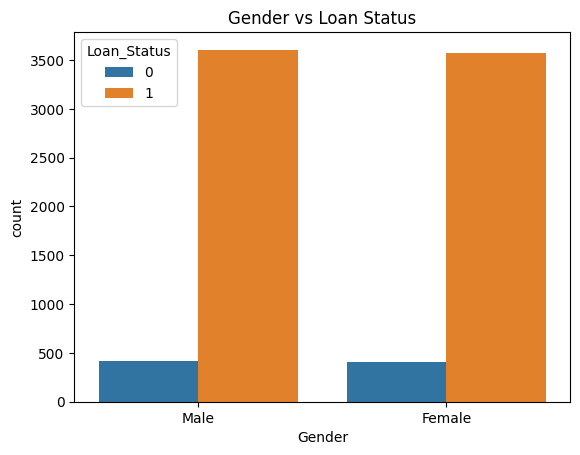

In [4]:
#Gender vs Loan Status
plt.figure()
sns.countplot(x="Gender", hue="Loan_Status", data=data)
plt.title("Gender vs Loan Status")
plt.show()

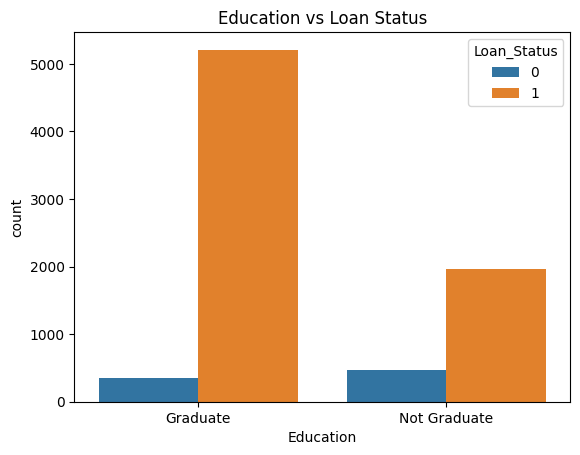

In [5]:
#Education vs Loan Status
plt.figure()
sns.countplot(x="Education", hue="Loan_Status", data=data)
plt.title("Education vs Loan Status")
plt.show()

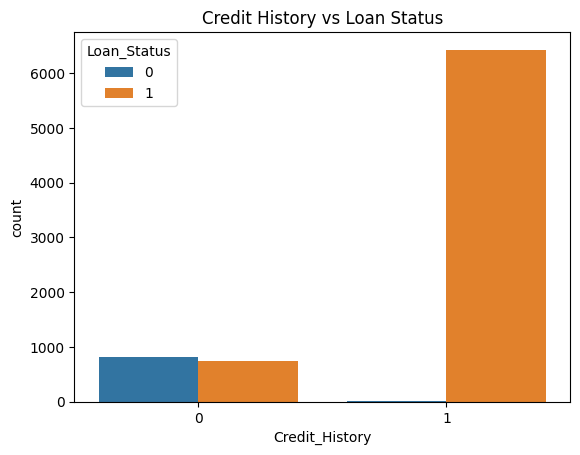

In [6]:
#Credit History vs Loan Status
plt.figure()
sns.countplot(x="Credit_History", hue="Loan_Status", data=data)
plt.title("Credit History vs Loan Status")
plt.show()

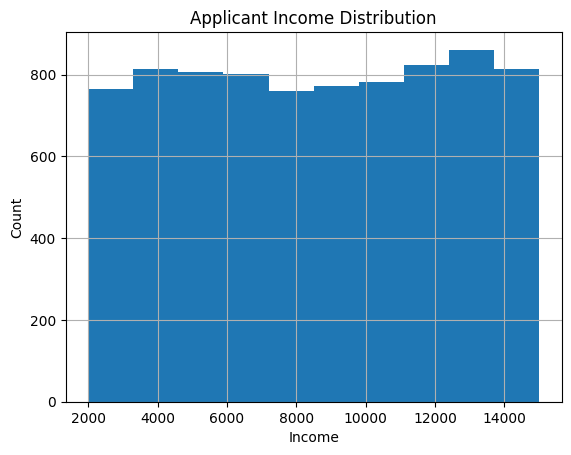

In [7]:
#Applicant Income Distribution
plt.figure()
data["ApplicantIncome"].hist()
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

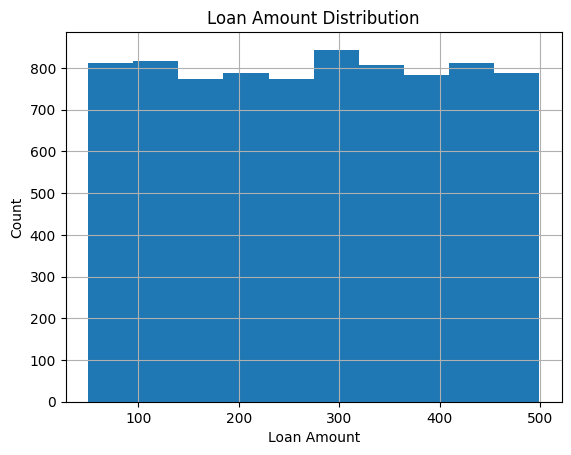

In [8]:
#Loan Amount Distribution
plt.figure()
data["LoanAmount"].hist()
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Count")
plt.show()

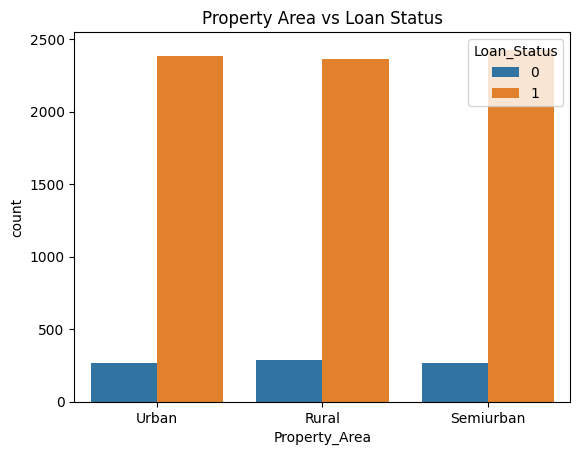

In [9]:
#Property Area vs Loan Status
plt.figure()
sns.countplot(x="Property_Area", hue="Loan_Status", data=data)
plt.title("Property Area vs Loan Status")
plt.show()

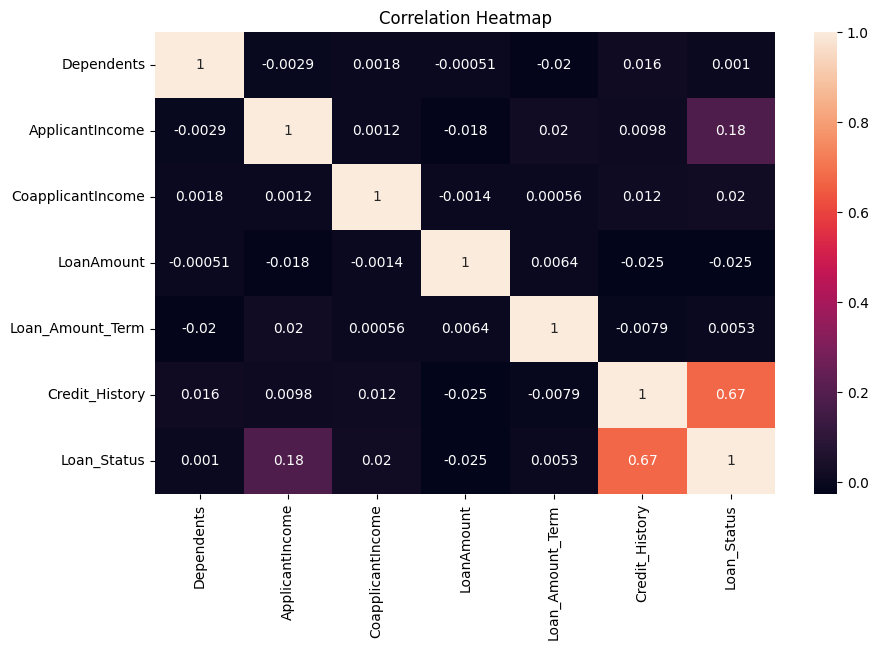

In [10]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.select_dtypes(include=np.number).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
#Encoding & Train-Test Split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Store encoders for reuse
encoders = {}

categorical_cols = ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]

for col in categorical_cols:
    encoders[col] = LabelEncoder()
    data[col] = encoders[col].fit_transform(data[col])

X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
#Train Model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [13]:
#Metrics
from sklearn.metrics import accuracy_score, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.994375


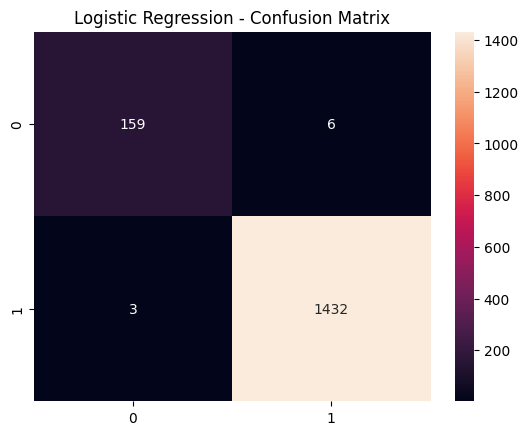

In [14]:
#Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

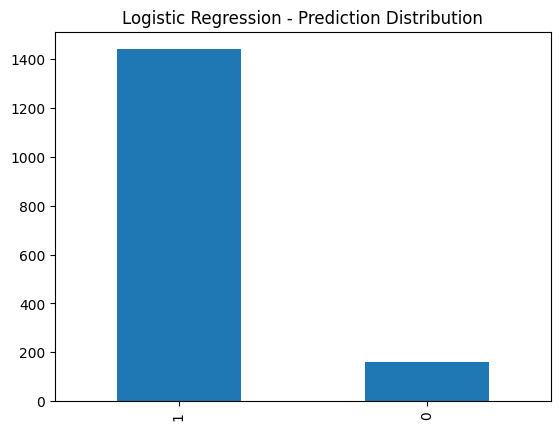

In [15]:
#Prediction Distribution
plt.figure()
pd.Series(y_pred_lr).value_counts().plot(kind="bar")
plt.title("Logistic Regression - Prediction Distribution")
plt.show()

In [16]:
#Train Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=6,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [17]:
#Accuracy
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.996875


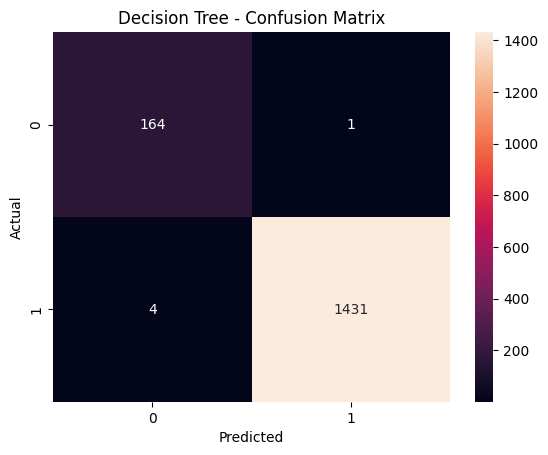

In [18]:
#(Decision Tree): Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

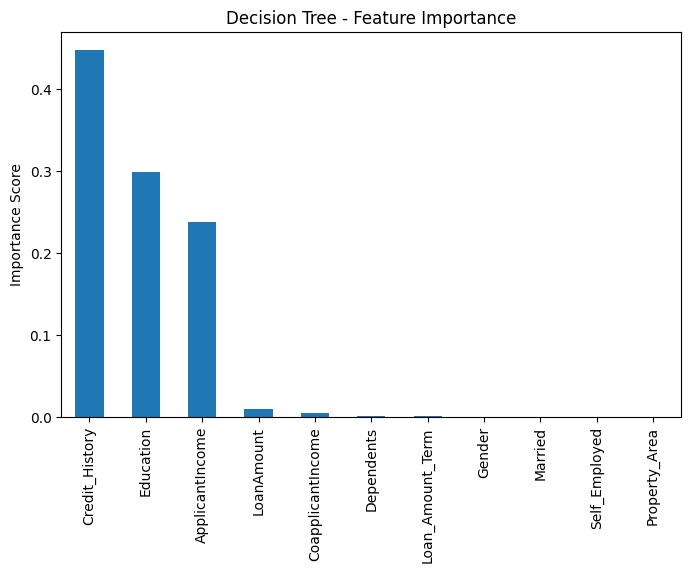

In [19]:
#(Decision Tree): Feature Importance
feature_importance = pd.Series(
    dt.feature_importances_,
    index=data.drop("Loan_Status", axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feature_importance.plot(kind="bar")
plt.title("Decision Tree - Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [20]:
#Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [21]:
#Accuracy
from sklearn.metrics import accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.99875


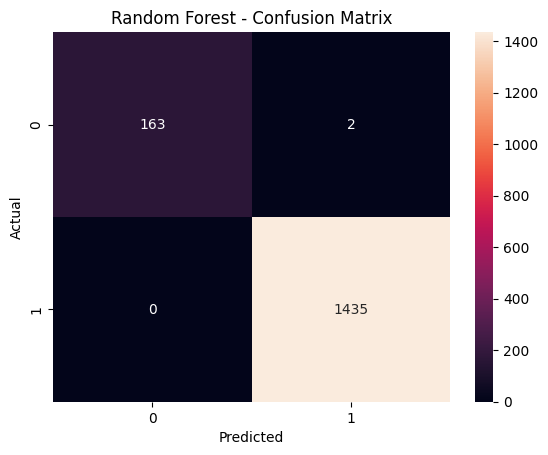

In [22]:
#(Random Forest): Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

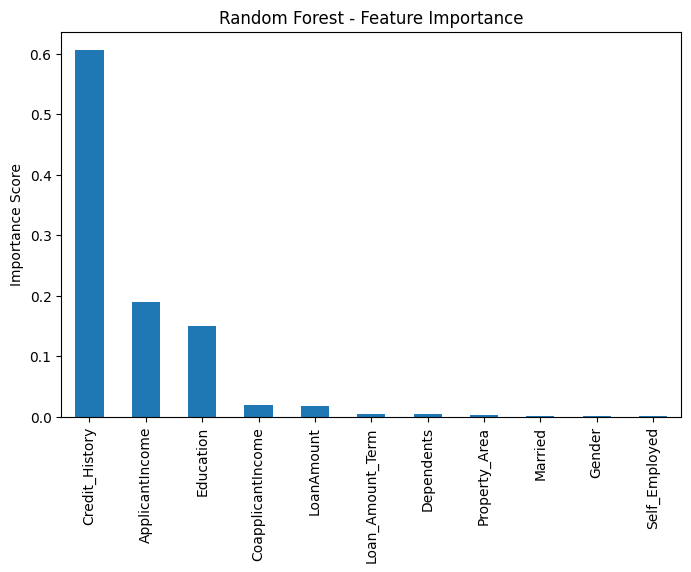

In [23]:
#(Random Forest): Feature Importance
rf_importance = pd.Series(
    rf.feature_importances_,
    index=data.drop("Loan_Status", axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
rf_importance.plot(kind="bar")
plt.title("Random Forest - Feature Importance")
plt.ylabel("Importance Score")
plt.show()

In [24]:
#Train SVM Model
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [25]:
#Accuracy
from sklearn.metrics import accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.993125


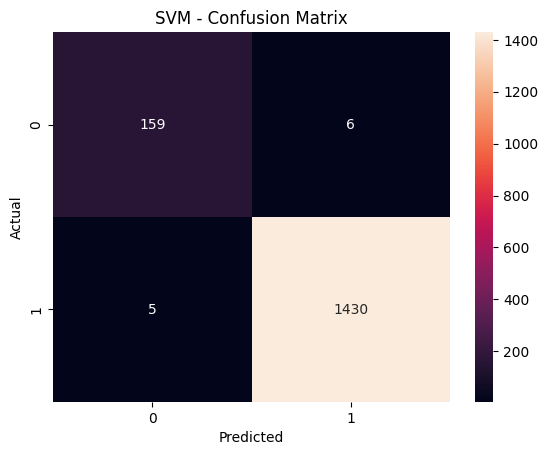

In [26]:
#(SVM): Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d")
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

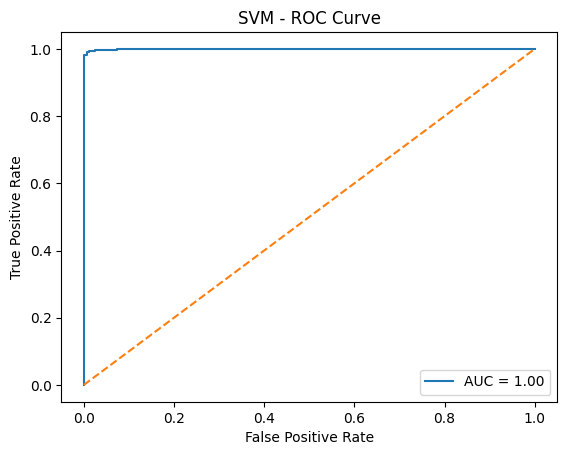

In [27]:
#(SVM): ROC Curve
from sklearn.metrics import roc_curve, auc

y_prob_svm = svm.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("SVM - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [29]:
#Build the Neural Network (5+ Layers)
model = Sequential()

model.add(Dense(128, activation="relu", input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))

model.add(Dense(1, activation="sigmoid"))  # Binary classification

model.summary()

C:\Users\rithu\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Compile the Model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [31]:
#Train the Model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9256 - loss: 0.2023 - val_accuracy: 0.9820 - val_loss: 0.0612
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9762 - loss: 0.0632 - val_accuracy: 0.9828 - val_loss: 0.0367
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9803 - loss: 0.0542 - val_accuracy: 0.9883 - val_loss: 0.0301
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9824 - loss: 0.0430 - val_accuracy: 0.9883 - val_loss: 0.0247
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9885 - loss: 0.0307 - val_accuracy: 0.9930 - val_loss: 0.0166
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9891 - loss: 0.0278 - val_accuracy: 0.9945 - val_loss: 0.0165
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9896 - loss: 0.0282 - val_accuracy: 0.9922 - val_loss: 0.0180
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9898 - loss: 0.0266 - val_accuracy: 0.

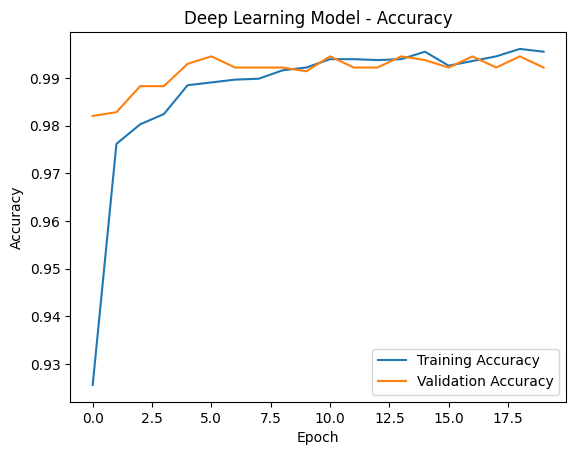

In [32]:
#Training vs Validation Accuracy
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Deep Learning Model - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

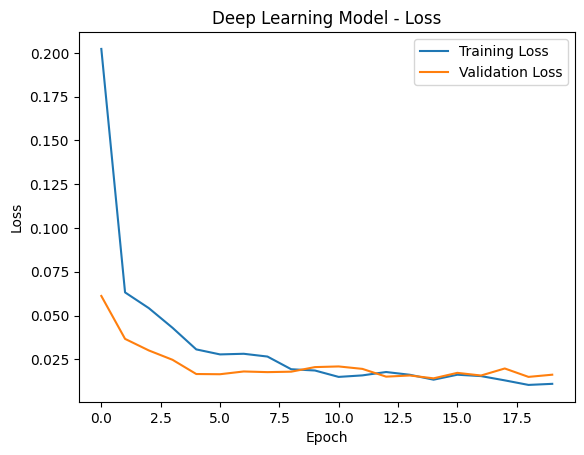

In [33]:
#Training vs Validation Loss
plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Deep Learning Model - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [34]:
#Evaluate Model on Test Data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Deep Learning Test Accuracy:", test_accuracy)

Deep Learning Test Accuracy: 0.9975000023841858


In [35]:
# ================= USER INPUT LOAN PREDICTION (FINAL ROBUST VERSION) =================

def user_loan_prediction():
    print("Enter Loan Applicant Details\n")

    # Normalize inputs (case handling)
    Gender = input("Gender (Male/Female): ").strip().capitalize()
    Married = input("Married (Yes/No): ").strip().capitalize()
    Education = input("Education (Graduate/Not Graduate): ").strip().title()
    Self_Employed = input("Self Employed (Yes/No): ").strip().capitalize()
    Property_Area = input("Property Area (Urban/Semiurban/Rural): ").strip().title()

    Dependents = int(input("Number of Dependents (0–3): "))
    ApplicantIncome = float(input("Applicant Income: "))
    CoapplicantIncome = float(input("Coapplicant Income: "))
    LoanAmount = float(input("Loan Amount: "))
    Loan_Amount_Term = float(input("Loan Amount Term (e.g. 360): "))
    Credit_History = int(input("Credit History (0 or 1): "))

    user_df = pd.DataFrame([{
        "Gender": Gender,
        "Married": Married,
        "Dependents": Dependents,
        "Education": Education,
        "Self_Employed": Self_Employed,
        "ApplicantIncome": ApplicantIncome,
        "CoapplicantIncome": CoapplicantIncome,
        "LoanAmount": LoanAmount,
        "Loan_Amount_Term": Loan_Amount_Term,
        "Credit_History": Credit_History,
        "Property_Area": Property_Area
    }])

    # Apply trained encoders
    for col in ["Gender", "Married", "Education", "Self_Employed", "Property_Area"]:
        user_df[col] = encoders[col].transform(user_df[col])

    # Scale
    user_scaled = scaler.transform(user_df)

    # Predict
    prediction = rf.predict(user_scaled)[0]
    probability = rf.predict_proba(user_scaled)[0][1]

    if prediction == 1:
        print(f"\n✅ LOAN APPROVED (Confidence: {probability:.2f})")
    else:
        print(f"\n❌ LOAN REJECTED (Confidence: {1 - probability:.2f})")


# Run
user_loan_prediction()

Enter Loan Applicant Details


❌ LOAN REJECTED (Confidence: 0.86)
